In [9]:
import cv2

# Load the image in grayscale
img = cv2.imread('cameraman.png', cv2.IMREAD_GRAYSCALE)


In [36]:
# Set the threshold values

threshold_values = [0, 50, 100, 150, 200]

# Apply thresholding with different threshold values
for threshold_value in threshold_values:
    ret, thresh = cv2.threshold(img, threshold_value, 255, cv2.THRESH_BINARY)
    cv2.imshow(f'Thresholded Image ({threshold_value})', thresh)



In [11]:
# Display the original image
cv2.imshow('Original Image', img)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [12]:
# Task#2: Histogram Processing

# Step#1: Load necessary libraries
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

from skimage import data, img_as_float
from skimage import exposure

# Step#2: Load moon image
img = data.moon()


/home/ibtisam/.pyenv/versions/ai/lib/python3.12/site-packages/skimage/color/colorconv.py:55: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.4.4)
  from scipy import linalg


In [13]:
# Step#3: Rescale intensity values to include all the intensities that fall within the 2nd and 98th percentiles
# Contrast stretching
p2, p98 = np.percentile(img, (2, 98))
img_rescale = exposure.rescale_intensity(img, in_range=(p2, p98))


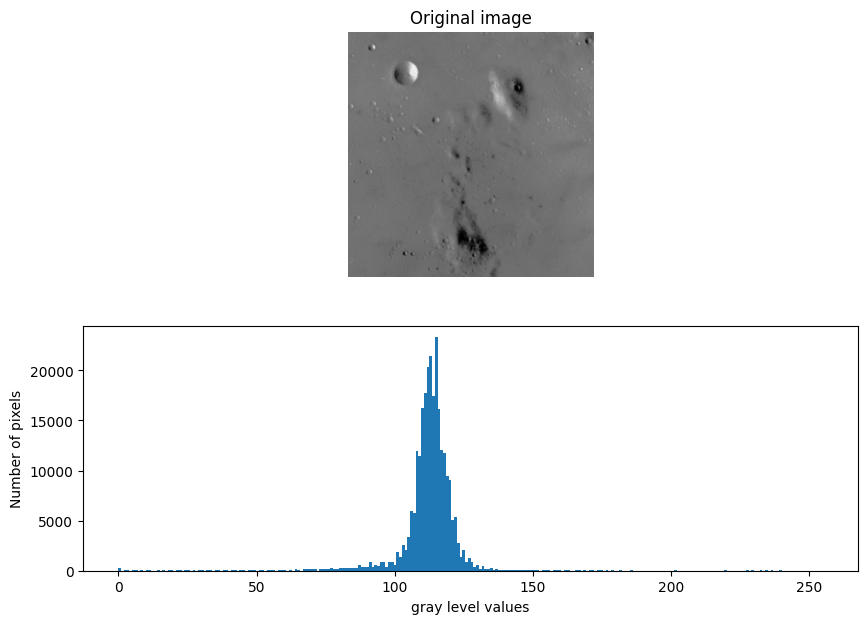

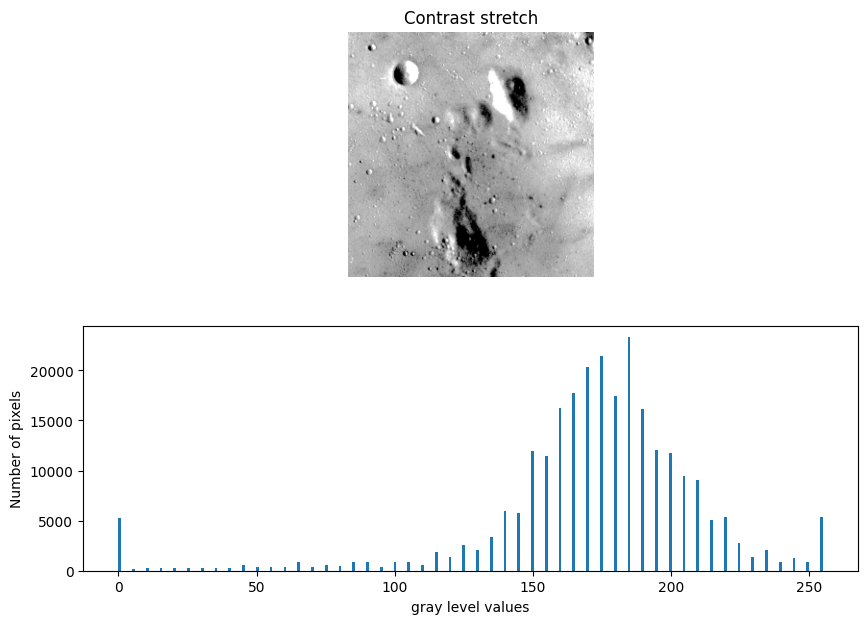

In [14]:
# Step#4: Display the image with its histogram of (step#2)  and (step#3)

fig = plt.figure(figsize=(10, 7)) 
fig.add_subplot(2, 1, 1) 
plt.imshow(img, cmap = 'gray') 
plt.axis('off') 
plt.title('Original image') 
fig.add_subplot(2, 1, 2) 
plt.hist(img.flat, bins = 256, range=(0, 255)) 
plt.xlabel('gray level values') 
plt.ylabel('Number of pixels') 
plt.show() 
fig = plt.figure(figsize=(10, 7)) 
fig.add_subplot(2, 1, 1) 
plt.imshow(img_rescale, cmap = 'gray') 
plt.axis('off') 
plt.title('Contrast stretch')
fig.add_subplot(2, 1, 2) 
plt.hist(img_rescale.flat, bins = 256, range=(0, 255)) 
plt.xlabel('gray level values') 
plt.ylabel('Number of pixels') 
plt.show() 

In [ ]:
# Task#1: Using the same ‘moon image’ Rescale intensity values to include all the intensities that fall within the 3nd and 80th percentiles, and plot the histogram

# Task#2: Using the same ‘moon image’ and the exposure.equalize_hist function, display the image and the histogram of the image after flattening the histogram.

# Task#3: Use the rocket (as reference) and chelsea images (from skimage.data) and implement histogram matching


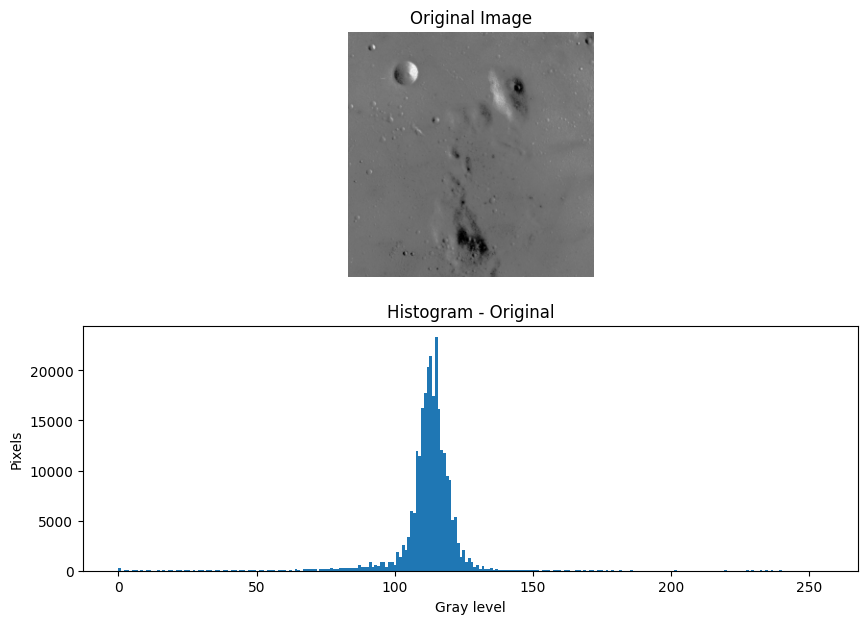

In [20]:
#Task1


p3 ,p80 = np.percentile(img , (3 , 80))
img_rescale= exposure.rescale_intensity(img, in_range=(p3, p80))
fig = plt.figure(figsize=(10, 7))

fig.add_subplot(2, 1, 1)
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis('off')

fig.add_subplot(2, 1, 2)
plt.hist(img.flat, bins=256, range=(0, 255))
plt.title("Histogram - Original")
plt.xlabel("Gray level")
plt.ylabel("Pixels")

plt.show()


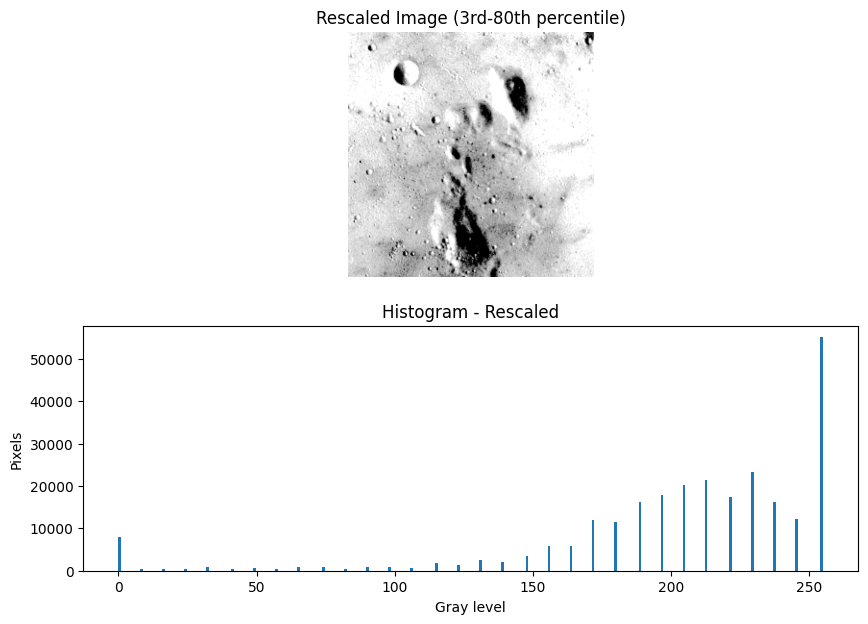

In [21]:

fig = plt.figure(figsize=(10, 7))

fig.add_subplot(2, 1, 1)
plt.imshow(img_rescale, cmap='gray')
plt.title("Rescaled Image (3rd-80th percentile)")
plt.axis('off')

fig.add_subplot(2, 1, 2)
plt.hist(img_rescale.flat, bins=256, range=(0, 255))
plt.title("Histogram - Rescaled")
plt.xlabel("Gray level")
plt.ylabel("Pixels")

plt.show()

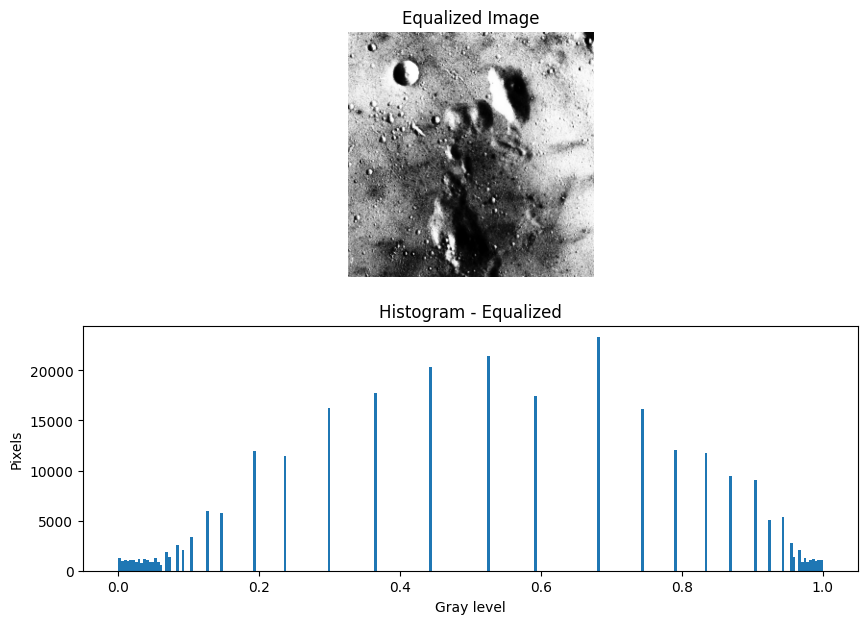

In [22]:
#Task2

# Histogram Equalization
img_eq = exposure.equalize_hist(img)

# Display image + histogram
fig = plt.figure(figsize=(10, 7))

fig.add_subplot(2, 1, 1)
plt.imshow(img_eq, cmap='gray')
plt.title("Equalized Image")
plt.axis('off')

fig.add_subplot(2, 1, 2)
plt.hist(img_eq.flat, bins=256)
plt.title("Histogram - Equalized")
plt.xlabel("Gray level")
plt.ylabel("Pixels")

plt.show()

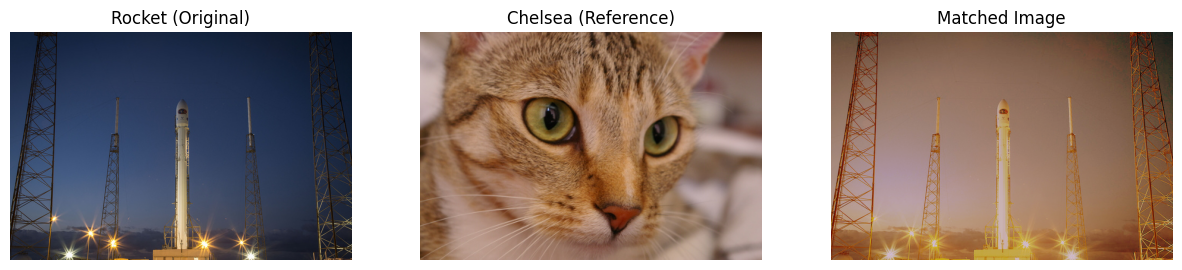

In [32]:
#Task3

rocket = data.rocket()
chelsea = data.chelsea()

matched = exposure.match_histograms(rocket, chelsea, channel_axis=-1)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(rocket)
axes[0].set_title("Rocket (Original)")
axes[0].axis("off")

axes[1].imshow(chelsea)
axes[1].set_title("Chelsea (Reference)")
axes[1].axis("off")

axes[2].imshow(matched)
axes[2].set_title("Matched Image")
axes[2].axis("off")

plt.show()